**Table of contents**<a id='toc0_'></a>    
- [Graphical abstract](#toc1_)    
  - [Color palette: Okabe-Ito](#toc1_1_)    
  - [Fingerprints](#toc1_2_)    
  - [Energy transfer](#toc1_3_)    
  - [Figure](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Graphical abstract](#toc0_)
...and specification of color palette

In [ ]:
import numpy as np
from scipy.stats import expon
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, RegularPolygon

import fluopy.figure as fi
import fluopy.miscellaneous as mi

%load_ext autoreload
%autoreload 2

for package in [fi, mi]:
    print(f"{package.__name__} version: {package.__version__}")

saving_at = r"D:\python_output\Chapter_I\0_0_graphical_abstract"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
fluopy.figure version: 0.1.0
fluopy.miscellaneous version: 0.1.0


## <a id='toc1_1_'></a>[Color palette: Okabe-Ito](#toc0_)


In [9]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
blue = "#0072B2"
yellow = "#F0E442"

## <a id='toc1_2_'></a>[Fingerprints](#toc0_)

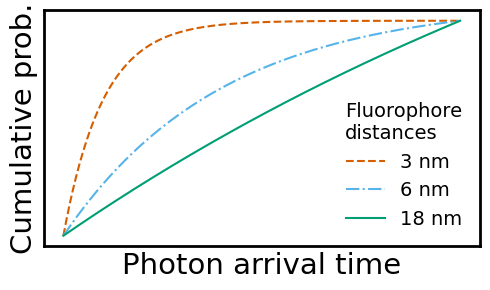

In [10]:
x = np.linspace(0, 10, 1000)
nm_3 = expon.cdf(x, scale=1)
nm_6 = expon.cdf(x, scale=4)
nm_18 = expon.cdf(x, scale=20)
ax = fi.universal_figure(
    data=[x, nm_3 / np.max(nm_3)], color=red, label="3 nm", ls="--", fig_width=5
)
fi.universal_figure(
    data=[x, nm_6 / np.max(nm_6)], color=sky_blue, label="6 nm", axes=ax, ls="-."
)
fi.universal_figure(
    data=[x, nm_18 / np.max(nm_18)],
    color=green,
    label="18 nm",
    axes=ax,
    xlabel="Photon arrival time",
    ylabel="Cumulative prob.",
    legend=True,
    xticks=[],
    yticks=[],
    legendargs={
        "frameon": False,
        "fontsize": 14,
        "title": "Fluorophore\ndistances",
        "title_fontsize": 14,
    },
)
fig = mi.get_figure(ax)
fig.tight_layout()
fig.savefig(saving_at + r"\graphical_abstract_fig_1.svg")

## <a id='toc1_3_'></a>[Energy transfer](#toc0_)

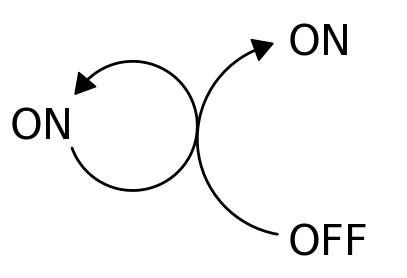

In [11]:
def drawCirc(radius, centX, centY, angle, theta2, color="black", orientation="left"):
    arc = Arc(
        [centX, centY],
        radius,
        radius,
        angle=angle,
        theta1=0,
        theta2=theta2,
        capstyle="round",
        linestyle="-",
        lw=2,
        color=color,
    )
    if orientation == "left":
        endX = centX + (radius / 2) * np.cos(np.radians(theta2 + angle))
        endY = centY + (radius / 2) * np.sin(np.radians(theta2 + angle))
        polygon = RegularPolygon(
            xy=(endX, endY),
            numVertices=3,
            radius=0.02,
            orientation=np.radians(angle + theta2),
            color=color,
        )
    else:
        endX = centX + (radius / 2) * np.cos(np.radians(angle))
        endY = centY + (radius / 2) * np.sin(np.radians(angle))
        polygon = RegularPolygon(
            xy=(endX, endY),
            numVertices=3,
            radius=0.02,
            orientation=np.radians(angle + 180),
            color=color,
        )
    return polygon, arc


fig, ax = plt.subplots(figsize=(5, 5))
ax.text(s="ON", x=0.2, y=0.5, fontsize=30)
ax.text(s="OFF", x=0.63, y=0.32, fontsize=30)
ax.text(s="ON", x=0.63, y=0.63, fontsize=30)
p, a = drawCirc(0.2, 0.39, 0.52, 200, 300, orientation="left")
ax.add_patch(p)
ax.add_patch(a)
p2, a2 = drawCirc(0.3, 0.64, 0.5, angle=110, theta2=150, orientation="right")
ax.add_patch(p2)
ax.add_patch(a2)
ax.axis("off")
ax.set_xlim(0.2, 0.8)
ax.set_ylim(0.3, 0.7)
ax.set_aspect(1)
fig.savefig(
    saving_at + r"\graphical_abstract_fig_2.svg", bbox_inches="tight", pad_inches=0
)

## <a id='toc1_4_'></a>[Figure](#toc0_)

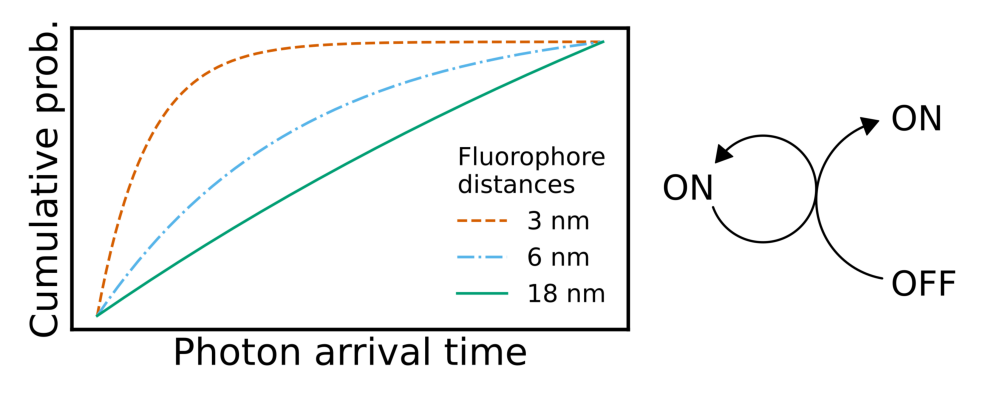

In [12]:
svg_files = ["graphical_abstract_fig_1.svg", "graphical_abstract_fig_2.svg"]

fig = fi.multi_plot(
    svg_files=svg_files,
    dpi=300,
    dims=(1, 2),
    figsize=(10, 5),
    width_ratios=[2, 1],
    height_ratios=None,
)
fig.tight_layout()
fig.savefig(
    saving_at + r"\graphical_abstract_fig.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0,
)